# Reading the Radar
### A hands-on guide to what weather radar sees — and misses

*Sebastián Torres · CIWRO, University of Oklahoma*  
*Clouds4Africa · July 2026*

---

**How to use this notebook.** Connect what you see on a radar display to the physics and system design behind it. Run the install cell, then the setup cell (once each), and work through the widgets in order. Each widget has three question levels — *Basic*, *A little further*, *Going deeper* — so start where you're comfortable and push as far as you can; they're meant to stretch, not to be finished. Time per widget is short, so don't expect to clear every level here; the more advanced questions are designed to be picked up again after the workshop. The notebook is yours to keep and re-run afterward.

<sub>© 2026 Sebastián Torres · Licensed under CC BY-NC 4.0 · Contact: sebas@ou.edu · Materials: https://sebastiantorr.github.io/Clouds4Africa/lab/index.html</sub>

In [6]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


# Block 5: Two polarizations
### What is the echo made of — not just how much?

Blocks 1–4 used a single polarization: they tell you *how much* is there. A dual-polarization radar transmits and receives both a horizontal and a vertical wave, and comparing the two reveals the *shape, variety, and phase* of what the beam hit — so the radar can finally tell rain from hail from a melting layer from birds, and rescue rainfall where single-pol fails. This block has three widgets. Run the setup cell once, then work through the widgets in order, since each builds on the last.

## Before we start
Dual-pol adds three new variables on top of reflectivity. Three ideas frame them.

1. **Two polarizations, one volume.** The radar measures the echo at horizontal (H) and vertical (V) polarization. On their own each is just reflectivity; it's the *comparison* of the two that carries the new information.

2. **Three new variables.** **ZDR** (differential reflectivity) — the *shape and size* of the scatterers. **ρhv** (correlation coefficient) — how *uniform* the mix is. **ΦDP** (differential phase) — a *phase* measure of rain that is immune to attenuation.

3. **From "how much" to "what is it."** Single-pol Z is ambiguous: hail and heavy rain can read the same. Dual-pol separates weather from non-weather, flags the melting layer, and — through KDP, the range derivative of ΦDP — fixes the attenuated rainfall estimates of Block 4.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown

EPS_M1 = 79.0    # water dielectric (eps - 1), real part — sets the ZDR scale

def axis_ratio(D_mm):
    # raindrop axis ratio b/a (vertical/horizontal): ~1 when small, flatter when large
    return np.clip(1.03 - 0.062*D_mm, 0.45, 1.0)

def _depol(gamma):
    # depolarization factors of an oblate spheroid (Lz = short/vertical axis, Lx = horizontal)
    gamma = np.clip(gamma, 1e-3, 0.9999); xi = np.sqrt(1.0/gamma**2 - 1.0)
    Lz = (1+xi**2)/xi**2 * (1 - np.arctan(xi)/xi)
    return (1 - Lz)/2, Lz

def zdr_from_D(D_mm):
    Lx, Lz = _depol(axis_ratio(D_mm)); k = 1.0/EPS_M1
    return 20*np.log10((Lz + k)/(Lx + k))     # differential reflectivity (dB)

def kdp_from_R(R):    return (R/44.0)**(1.0/0.82)   # deg/km  (so R = 44*KDP^0.82 inverts exactly)
def R_from_kdp(KDP):  return 44.0*np.maximum(KDP, 0)**0.82

print("Block 5 ready | ZDR of a 5 mm drop:", round(float(zdr_from_D(5)),2), "dB",
      "| KDP at 50 mm/h:", round(float(kdp_from_R(50)),2), "deg/km")

Block 5 ready | ZDR of a 5 mm drop: 3.24 dB | KDP at 50 mm/h: 1.17 deg/km


## 1 — Shape: differential reflectivity (ZDR)

Raindrops aren't spheres — the bigger they are, the more they flatten as they fall, like a hamburger bun. A horizontally-polarized wave sees a wider target than a vertical one, so the horizontal echo is stronger: that difference, in dB, is **ZDR**. It depends on the *shape and size* of the drops, **not** on how many there are.

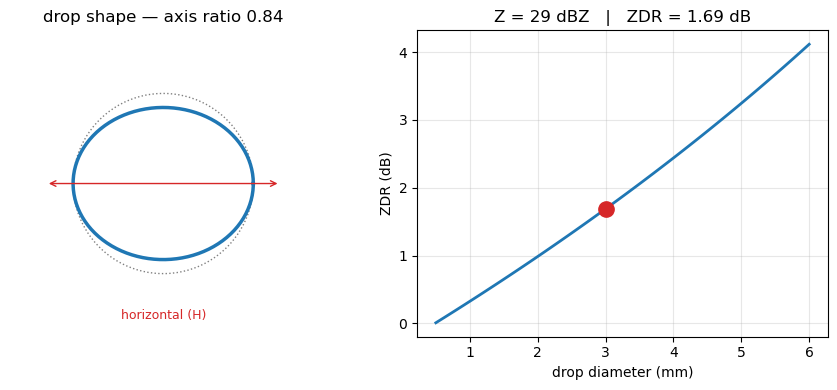

interactive(children=(FloatSlider(value=3.0, description='drop mm', max=6.0, min=0.5), FloatSlider(value=3.0, …

In [8]:
def show_zdr(drop_mm=3.0, logN=3.0):
    g = float(axis_ratio(drop_mm)); zdr = float(zdr_from_D(drop_mm))
    Z = 10*np.log10(10**logN * drop_mm**6 * 1e-3 + 1e-9)   # representative reflectivity (dBZ)
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(9, 4))
    th = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(th), np.sin(th), ls=":", lw=1, color="gray")        # reference sphere
    ax.plot(np.cos(th), g*np.sin(th), lw=2.5, color="tab:blue")        # actual drop
    ax.annotate("", (1.3,0), (-1.3,0), arrowprops=dict(arrowstyle="<->", color="tab:red"))
    ax.text(0, -1.5, "horizontal (H)", ha="center", color="tab:red", fontsize=9)
    ax.set_aspect("equal"); ax.set_xlim(-1.7,1.7); ax.set_ylim(-1.7,1.7); ax.axis("off")
    ax.set_title("drop shape — axis ratio " + str(round(g,2)))
    D = np.linspace(0.5, 6, 120)
    bx.plot(D, [zdr_from_D(d) for d in D], lw=2)
    bx.plot([drop_mm], [zdr], "o", ms=11, color="tab:red")
    bx.set_xlabel("drop diameter (mm)"); bx.set_ylabel("ZDR (dB)"); bx.grid(alpha=0.3)
    bx.set_title("Z = " + str(round(Z)) + " dBZ   |   ZDR = " + str(round(zdr,2)) + " dB")
    plt.tight_layout(); plt.show()

interact(show_zdr,
         drop_mm=FloatSlider(value=3.0, min=0.5, max=6, step=0.1, description="drop mm"),
         logN=FloatSlider(value=3.0, min=1, max=5, step=0.5, description="log N (amount)"));

**Basic**

1. Slide the drop size from 1 mm to 6 mm. What happens to the drop's shape, and to ZDR?
2. Now change the amount of rain (log N) at a fixed drop size. Does Z change? Does ZDR change? What does that tell you about what ZDR actually measures?

**A little further**

1. A small-drop drizzle and a big-drop shower can share the same reflectivity Z. How would ZDR tell them apart — and why does that matter for estimating rain rate?
2. Hail tumbles as it falls, so on average it looks round to the radar. What ZDR would you expect from a hailstone, compared with a big raindrop of the same Z?

**Going deeper**

1. ZDR is a *ratio* of H to V power, so it's independent of calibration and of concentration. Confirm on the widget that raising log N by 1 lifts Z by 10 dB while ZDR doesn't move. Why is an intensive (ratio) variable more robust than an extensive one like Z?
2. Drop shape ties ZDR closely to median drop size. Sketch how combining Z (which depends on size *and* number) with ZDR (which pins the size) lets you solve for both the drop size and the concentration — something single-pol Z alone cannot do.

## 2 — Variety: the correlation coefficient (ρhv)

**ρhv** measures how alike the H and V returns are across the whole sample volume. If every particle is the same kind — all raindrops — H and V move in lockstep and ρhv ≈ 1. Mix in something different — hail among rain, half-melted snow, or non-weather like birds and ground clutter — and the correlation drops. ρhv is the radar's *purity meter*. Slide the particle variety up and watch it fall.

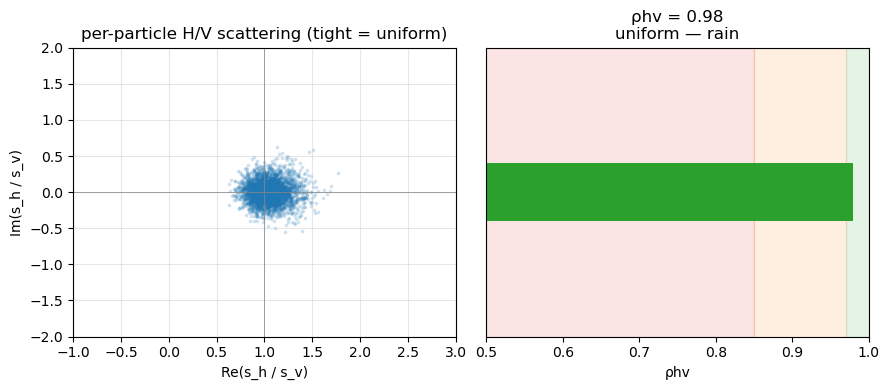

interactive(children=(FloatSlider(value=0.1, description='variety', max=1.2, step=0.02), Output()), _dom_class…

In [9]:
def show_rhohv(variety=0.1):
    rng = np.random.default_rng(0); Mn = 3000; g0 = 0.95
    sh = 1.0 + variety*(rng.standard_normal(Mn) + 1j*rng.standard_normal(Mn))
    sv = g0  + variety*(rng.standard_normal(Mn) + 1j*rng.standard_normal(Mn))
    rho = float(np.abs(np.mean(sh*np.conj(sv))) /
                np.sqrt(np.mean(np.abs(sh)**2)*np.mean(np.abs(sv)**2)))
    if   rho > 0.97: reg, col = "uniform — rain", "tab:green"
    elif rho > 0.85: reg, col = "mixed — hail or melting layer", "tab:orange"
    else:            reg, col = "non-meteorological — clutter, birds, insects", "tab:red"
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(9, 4))
    r = sh/sv
    ax.scatter(r.real, r.imag, s=3, alpha=0.15, color="tab:blue")
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(1, color="gray", lw=0.5)
    ax.set_xlim(-1, 3); ax.set_ylim(-2, 2); ax.grid(alpha=0.3)
    ax.set_xlabel("Re(s_h / s_v)"); ax.set_ylabel("Im(s_h / s_v)")
    ax.set_title("per-particle H/V scattering (tight = uniform)")
    bx.axvspan(0.97, 1.0, color="tab:green", alpha=0.12)
    bx.axvspan(0.85, 0.97, color="tab:orange", alpha=0.12)
    bx.axvspan(0.5, 0.85, color="tab:red", alpha=0.12)
    bx.barh([0], [rho-0.5], left=0.5, height=0.4, color=col)
    bx.set_xlim(0.5, 1.0); bx.set_ylim(-1, 1); bx.set_yticks([]); bx.set_xlabel("ρhv")
    bx.set_title("ρhv = " + str(round(rho,3)) + "\n" + reg)
    plt.tight_layout(); plt.show()

interact(show_rhohv,
         variety=FloatSlider(value=0.1, min=0.0, max=1.2, step=0.02, description="variety"));

**Basic**

1. At low variety, what is ρhv, and what kind of target does that value represent?
2. Raise the variety and watch the cloud spread and ρhv fall. At roughly what ρhv does the label switch from rain to a mixture?

**A little further**

1. A ρhv near 0.95 sits between pure rain and clutter. Name two *weather* situations that produce intermediate ρhv (think mixtures of particle types).
2. Why is ρhv the best single variable for spotting non-meteorological echoes — birds, insects, ground clutter, chaff? Roughly what values flag them?

**Going deeper**

1. ρhv is a correlation: it falls whenever the H/V ratio *varies* across the volume — not because any one particle is odd, but because the mix is diverse. Explain why a melting layer (the bright band) shows low ρhv, and why that makes ρhv a cleaner melting-layer detector than reflectivity.
2. A resolution volume far from the radar is huge (Block 2). Argue how beam broadening alone could lower ρhv by sweeping more particle types into one gate — and why ρhv must always be read alongside the sample size.

## 3 — Phase: specific differential phase (KDP) and rainfall

As the horizontal wave travels through flattened raindrops it is slowed slightly more than the vertical wave, so a differential phase **ΦDP** builds up along the path. Its slope, **KDP**, is proportional to rain rate. Because it's a *phase* measurement, KDP is immune to the attenuation and calibration errors that corrupt Z — the dual-pol answer to Block 4's shadow.

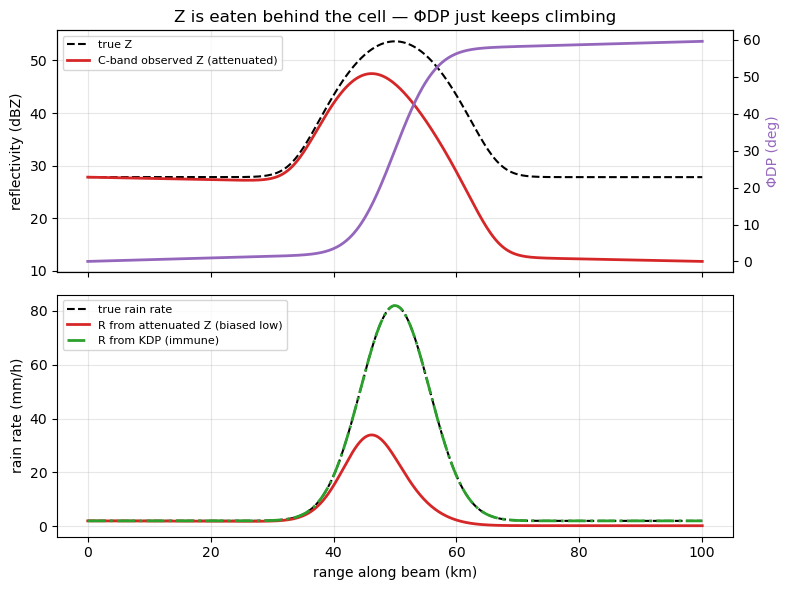

interactive(children=(FloatSlider(value=80.0, description='peak mm/h', max=150.0, min=10.0, step=5.0), Dropdow…

In [10]:
def show_kdp(peak_mmh=80, band="C"):
    x = np.linspace(0, 100, 500)
    R = 2 + peak_mmh*np.exp(-((x-50)/8)**2)              # a rain cell along the beam
    Z_true = 10*np.log10(200*R**1.6)
    a_att = {"C": 0.006, "X": 0.03}[band]
    pia = 2*np.cumsum(a_att*R*np.gradient(x))            # two-way attenuation (dB)
    Z_obs = Z_true - pia
    KDP = kdp_from_R(R)
    phidp = 2*np.cumsum(KDP*np.gradient(x))              # two-way differential phase (deg)
    R_fromZ = (10**(Z_obs/10)/200.0)**(1/1.6)            # biased low behind the cell
    R_fromK = R_from_kdp(KDP)                            # immune to attenuation
    fig, (ax, bx) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    ax.plot(x, Z_true, "k--", label="true Z")
    ax.plot(x, Z_obs, color="tab:red", lw=2, label=band + "-band observed Z (attenuated)")
    ax.set_ylabel("reflectivity (dBZ)"); ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3)
    ax.set_title("Z is eaten behind the cell — ΦDP just keeps climbing")
    ax2 = ax.twinx(); ax2.plot(x, phidp, color="tab:purple", lw=2)
    ax2.set_ylabel("ΦDP (deg)", color="tab:purple")
    bx.plot(x, R, "k--", label="true rain rate")
    bx.plot(x, R_fromZ, color="tab:red", lw=2, label="R from attenuated Z (biased low)")
    bx.plot(x, R_fromK, color="tab:green", lw=2, ls="-.", label="R from KDP (immune)")
    bx.set_xlabel("range along beam (km)"); bx.set_ylabel("rain rate (mm/h)")
    bx.legend(loc="upper left", fontsize=8); bx.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_kdp,
         peak_mmh=FloatSlider(value=80, min=10, max=150, step=5, description="peak mm/h"),
         band=Dropdown(options=["C", "X"], value="C", description="band"));

**Basic**

1. Raise the peak rain rate. What happens to the observed Z behind the cell (recall Block 4), and what happens to ΦDP?
2. Compare the two rain-rate estimates behind the cell — R from Z and R from KDP. Which one tracks the truth?

**A little further**

1. Switch from C-band to X-band. The Z-based rain rate gets worse behind the cell — why does the KDP-based one stay correct?
2. ΦDP only ever rises along the path and never comes back down. Why is a quantity that only accumulates more robust than Z, which can be knocked down by attenuation, miscalibration, or partial beam blocking (Block 1)?

**Going deeper**

1. KDP is the *slope* of ΦDP, so it needs ΦDP to change across several gates — it's noisy in light rain and undefined in no rain. Explain why KDP excels in heavy rain (where Z-based estimates fail most) but is poor for drizzle, and how you'd blend Z, ZDR, and KDP to cover all intensities.
2. Behind a heavy C-band core, Z is attenuated (biased low) and ZDR is also reduced by *differential* attenuation — yet KDP is untouched. Explain why a phase measurement survives where both power measurements fail, and why that makes KDP the workhorse for rainfall on the C-band networks this workshop serves.

## 4 — Radar data: inside one cell (KTLX, 20 May 2013, 0.48°)

The four panels zoom into the main cell at 20:16 UTC: reflectivity (Z), differential
reflectivity (ZDR), correlation (ρhv), and differential phase (ΦDP). Single-pol gives only
Z; the other three say what the cell is made of. Read the patterns.

**Basic**

1. Find the intense core — red, with a magenta 60+ dBZ patch. Now check its ρhv (bottom left):
   is it high (~1.0) or lowered? A high, uniform ρhv there says the core is mostly rain, not a
   chaotic hail mix — even though Z is very high.
2. Look at ZDR in the core and along the cell's leading (south-west) edge: moderate-to-high
   positive ZDR means large, flattened raindrops. Why can Z alone not tell heavy rain from
   hail, while ZDR and ρhv together can?

**A little further**

1. In ΦDP (bottom right), trace a radial outward through the heavy core: it ramps from low
   (teal, ~20°) up to high (orange–red, ~180°). That climb is differential phase accumulating
   through rain, and its slope is KDP — the attenuation-immune rain measure from Widget 3. Why
   does ΦDP keep rising through the core even where Z may be biased low?
2. Compare the clean, high-ρhv core with the speckled ZDR and patchy low ρhv at the cell's
   faint edges. Is that edge variety real weather, or noise? Why do the dual-pol variables turn
   unreliable where the echo is weak — and how should that change how far you trust them there?

**Going deeper**

1. Classify the core from all three: high Z + moderate-to-high ZDR + high ρhv = heavy rain with
   big drops, not hail (hail would drop both ZDR and ρhv). State that signature, and explain
   why the 60 dBZ core alone would tempt a single-pol radar into calling hail.
2. Tie it to Block 4: behind this core ΦDP is already high, so the beam has crossed heavy rain
   and Z there is probably attenuated — yet KDP, the slope of ΦDP, still recovers the rain
   rate. Explain why you'd trust a KDP-based rain estimate behind the core over a Z-based one,
   and why that matters most for C-band networks.

![Image](https://raw.githubusercontent.com/sebastiantorr/Clouds4Africa/main/content/block5_image1.png)

## Block 5 takeaway
**A single polarization tells you how much; two polarizations tell you what it is — ZDR reads the shape and size, ρhv reads the variety (and flags non-weather and the melting layer), and KDP measures rain through a phase that attenuation can't touch.**